In [1]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving Country-data.csv to Country-data.csv
{'Country-data.csv': b'country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp\r\nAfghanistan,90.2,10,7.58,44.9,1610,9.44,56.2,5.82,553\r\nAlbania,16.6,28,6.55,48.6,9930,4.49,76.3,1.65,4090\r\nAlgeria,27.3,38.4,4.17,31.4,12900,16.1,76.5,2.89,4460\r\nAngola,119,62.3,2.85,42.9,5900,22.4,60.1,6.16,3530\r\nAntigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200\r\nArgentina,14.5,18.9,8.1,16,18700,20.9,75.8,2.37,10300\r\nArmenia,18.1,20.8,4.4,45.3,6700,7.77,73.3,1.69,3220\r\nAustralia,4.8,19.8,8.73,20.9,41400,1.16,82,1.93,51900\r\nAustria,4.3,51.3,11,47.8,43200,0.873,80.5,1.44,46900\r\nAzerbaijan,39.2,54.3,5.88,20.7,16000,13.8,69.1,1.92,5840\r\nBahamas,13.8,35,7.89,43.7,22900,-0.393,73.8,1.86,28000\r\nBahrain,8.6,69.5,4.97,50.9,41100,7.44,76,2.16,20700\r\nBangladesh,49.4,16,3.52,21.8,2440,7.14,70.4,2.33,758\r\nBarbados,14.2,39.5,7.97,48.7,15300,0.321,76.7,1.78,16000\r\nBelarus,5.5,51.4,5.61,64.5,16200,15.1,7

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv("Country-data.csv")

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [5]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [6]:
countries = df["country"]

X = df.drop("country", axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

clusters = dbscan.fit_predict(X_scaled)

In [20]:
df["Cluster"] = clusters

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,Cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,-1
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


In [21]:
df["Cluster"].value_counts()

,count
Cluster,
1,75
-1,53
0,21
2,18


In [22]:
n_clusters = len(set(clusters))

if -1 in clusters:
    n_clusters -= 1

print("Number of Clusters:", n_clusters)

Number of Clusters: 3


In [23]:
noise_points = list(clusters).count(-1)

print("Noise Points:", noise_points)

Noise Points: 53


In [24]:
for cluster in sorted(df["Cluster"].unique()):

    print("\n")
    print("="*50)

    if cluster == -1:
        print("Noise Points")
    else:
        print(f"Cluster {cluster}")

    print("="*50)

    print(df[df["Cluster"] == cluster]["country"])



Noise Points
3                        Angola
11                      Bahrain
14                      Belarus
15                      Belgium
21                     Botswana
23                       Brunei
26                      Burundi
31     Central African Republic
37             Congo, Dem. Rep.
38                  Congo, Rep.
49            Equatorial Guinea
50                      Eritrea
55                        Gabon
66                        Haiti
72                         Iraq
73                      Ireland
78                       Jordan
81                     Kiribati
82                       Kuwait
84                          Lao
87                      Lesotho
88                      Liberia
89                        Libya
91                   Luxembourg
98                        Malta
99                   Mauritania
101       Micronesia, Fed. Sts.
102                     Moldova
103                    Mongolia
107                     Myanmar
113                     N

In [25]:
noise_countries = df[df["Cluster"] == -1]

noise_countries["country"]

,country
3,Angola
11,Bahrain
14,Belarus
15,Belgium
21,Botswana
23,Brunei
26,Burundi
31,Central African Republic
37,"Congo, Dem. Rep."
38,"Congo, Rep."


In [26]:
cluster_summary = df[df["Cluster"] != -1].groupby("Cluster").mean(numeric_only=True)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,96.719048,24.776190,5.679048,38.809524,1830.571429,7.043095,58.800000,5.479048,772.380952
1,20.514667,40.161067,6.366267,46.638667,12878.533333,5.960187,73.393333,2.184267,7457.653333
2,4.172222,35.627778,10.168889,34.494444,37338.888889,1.364222,81.011111,1.796667,41150.000000


In [27]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

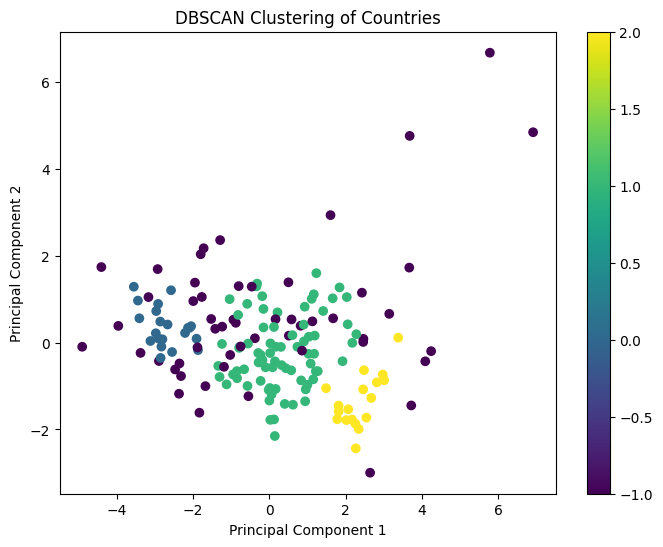

In [28]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.colorbar(scatter)

plt.title("DBSCAN Clustering of Countries")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [29]:
df["Cluster"].value_counts()

,count
Cluster,
1,75
-1,53
0,21
2,18
